In [1]:
#Upload data from drive
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
drive_path = '/content/drive/My Drive/Programacion/Actuary/freMTPL2/'
df_freq = pd.read_csv(drive_path + 'freMTPL2freq.csv')  #Frequency
df_sev = pd.read_csv(drive_path + 'freMTPL2sev.csv')    #Severity

Mounted at /content/drive


In [ ]:
#Extra Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset frecuencia:** Registra los datos de cada cliente, que auto tiene, donde vive y durante cuanto tiempo estuvo cubierto (Exposure)

La variable "ClaimNb" es la cantidad de siniestros. Cuantas veces esa poliza en particular reclamó un choque durante su tiempo activa.

**Dataset severidad:** Solo contiene informacion de los accidentes que costaron dinero. Cada fila es un siniestro individual que ya ocurrió y que la empresa tuvo que pagar.

In [131]:
print("------Severity data------")
print(df_sev.head(3))
print("\n------Frequency data------")
print(df_freq.head(5))

------Severity data------
     IDpol  ClaimAmount
0     1552       995,20
1  1010996     1.128,12
2  4024277     1.851,11

------Frequency data------
   IDpol  ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus VehBrand  \
0   1,00        1      0,10         5       0       55          50      B12   
1   3,00        1      0,77         5       0       55          50      B12   
2   5,00        1      0,75         6       2       52          50      B12   
3  10,00        1      0,09         7       0       46          50      B12   
4  11,00        1      0,84         7       0       46          50      B12   

    VehGas Area  Density       Region ClaimNb_Grouped  
0  Regular    D     1217  Rhone-Alpes               1  
1  Regular    D     1217  Rhone-Alpes               1  
2   Diesel    B       54     Picardie               1  
3   Diesel    B       76    Aquitaine               1  
4   Diesel    B       76    Aquitaine               1  


In [110]:
total_exposure = df_freq['Exposure'].sum()
total_claims = df_freq['ClaimNb'].sum()
portfolio_frequency = total_claims / total_exposure
print(f"Total pólizas    : {len(df_freq)}")
print(f"Total siniestros :  {total_claims}      siniestros")
print(f"Exposición total : {total_exposure.sum():.2f}  años poliza ")
print(f'Frecuencia media : {portfolio_frequency * 100:.2f}%     [ Siniestros / Exposición ]')

Total pólizas    : 678013
Total siniestros :  36102      siniestros
Exposición total : 358499.45  años poliza 
Frecuencia media : 10.07%     [ Siniestros / Exposición ]


In [113]:
total_claim_amount = df_sev['ClaimAmount'].sum()
global_severity = total_claim_amount / total_claims
print(f"Costo Total de Siniestros  : €{total_claim_amount:,.2f}")
print(f"Severidad Media Global     : {global_severity:,.2f}")

Costo Total de Siniestros  : €60,697,930.68
Severidad Media Global     : 1,681.29


/tmp/ipykernel_1838/1384905486.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


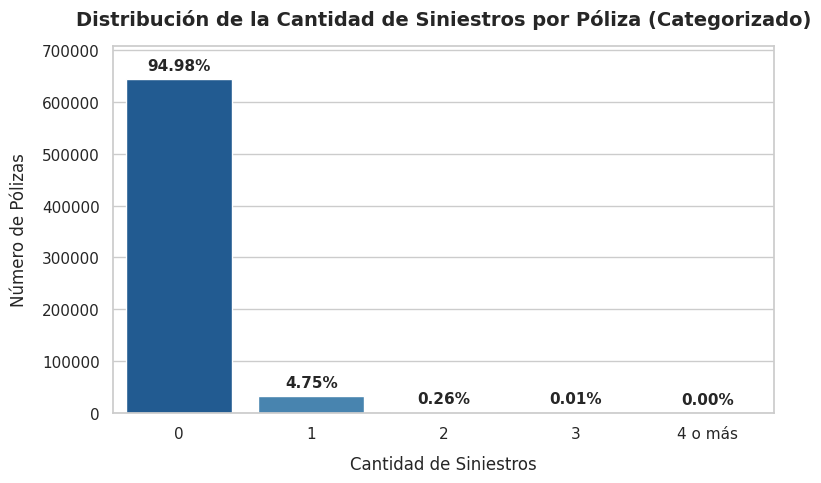

In [129]:
# ==============================================================================
# GRAFICO: DISTRIBUCIÓN DE FRECUENCIA AGRUPADA
# ==============================================================================
def agrupar_siniestros(x):
    if x >= 4:
        return '4 o más'
    return str(x)
# Aplicamos la función en una columna nueva del dataframe
df_freq['ClaimNb_Grouped'] = df_freq['ClaimNb'].apply(agrupar_siniestros)
# Definimos el orden exacto en el que queremos que aparezcan las barras
orden_eje_x = ['0', '1', '2', '3', '4 o más']
# 2. Armamos el gráfico independiente
plt.figure(figsize=(8, 5))
# Usamos una paleta de azules que vaya de oscuro (más común) a claro (menos común)
ax = sns.countplot(
    data=df_freq,
    x='ClaimNb_Grouped',
    order=orden_eje_x,
    palette='Blues_r'
)
# 3. Estética y etiquetas
plt.title('Distribución de la Cantidad de Siniestros por Póliza (Categorizado)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Siniestros', fontsize=12, labelpad=10)
plt.ylabel('Número de Pólizas', fontsize=12, labelpad=10)

# Añadimos los porcentajes arriba de cada barra con formato local (, para decimales)
total_polizas = len(df_freq)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total_polizas:.2f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11,
        fontweight='semibold'
    )
# Ajustamos los límites del eje Y para dejar espacio a las etiquetas de porcentaje
plt.ylim(0, df_freq['ClaimNb_Grouped'].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

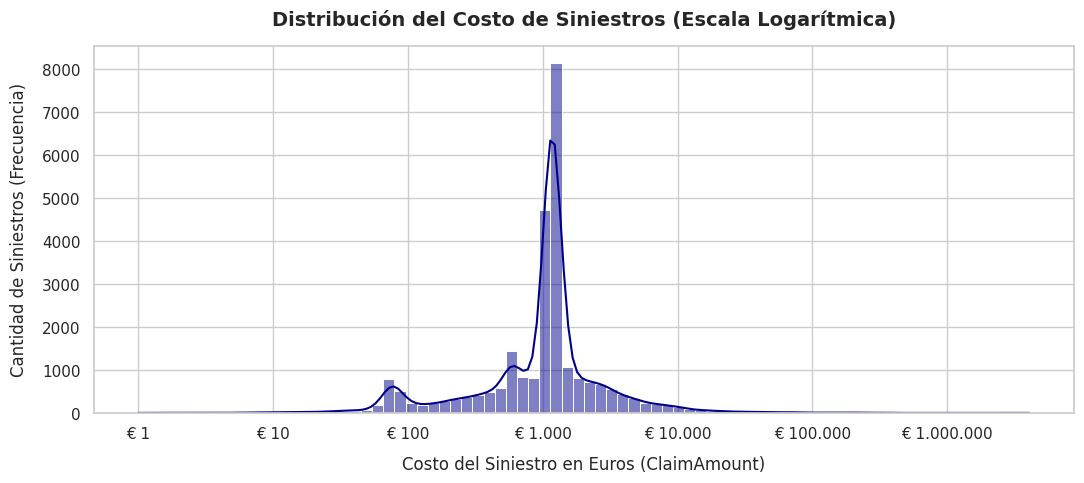

In [128]:
# ==============================================================================
# GRAFICO: DISTRIBUCIÓN DE SEVERIDAD (COSTO DE SINIESTROS)
# ==============================================================================
plt.figure(figsize=(11, 5))

# Dibujamos el histograma (se mantiene igual, impecable)
ax = sns.histplot(
    data=df_sev,
    x='ClaimAmount',
    bins=80,
    kde=True,
    color='darkblue',
    log_scale=True
)

plt.title('Distribución del Costo de Siniestros (Escala Logarítmica)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Costo del Siniestro en Euros (ClaimAmount)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Siniestros (Frecuencia)', fontsize=12, labelpad=10)

# --- REPARACIÓN DEL EJE X ---
# Avanzamos multiplicando por 10. Esto garantiza la simetría visual en log-scale.
ticks_euros = [1, 10, 100, 1000, 10000, 100000, 1000000]

# Formateamos las etiquetas en Euros con formato local argentino
labels_euros = [f"€ {t:,}".replace(',', '.') for t in ticks_euros]

# Aplicamos los ticks corregidos (rotación a 0 porque ahora hay espacio de sobra)
plt.xticks(ticks_euros, labels_euros, rotation=0)

plt.tight_layout()
plt.show()

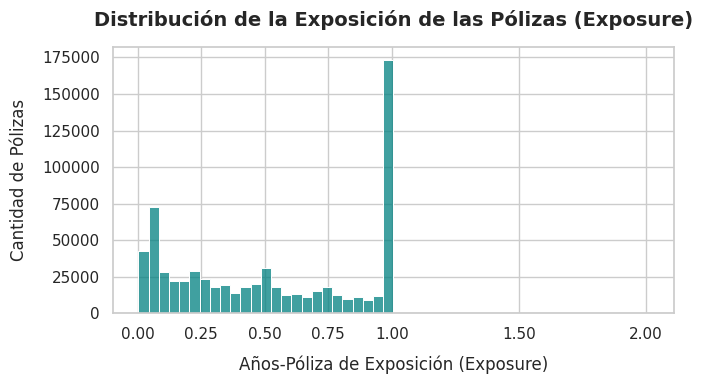

In [123]:
# ==============================================================================
# GRAFICO: ANÁLISIS DE LA EXPOSICIÓN (EXPOSURE)
# ==============================================================================
plt.figure(figsize=(7, 4))

# Dibujamos el histograma de la exposición
ax = sns.histplot(
    data=df_freq,
    x='Exposure',
    bins=50,
    kde=False,
    color='teal'
)

plt.title('Distribución de la Exposición de las Pólizas (Exposure)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Años-Póliza de Exposición (Exposure)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Pólizas', fontsize=12, labelpad=10)

# Forzamos los ticks del eje X para ver bien los puntos clave (0, 0.5, 1, 2)
plt.xticks([0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0])

plt.tight_layout()
plt.show()

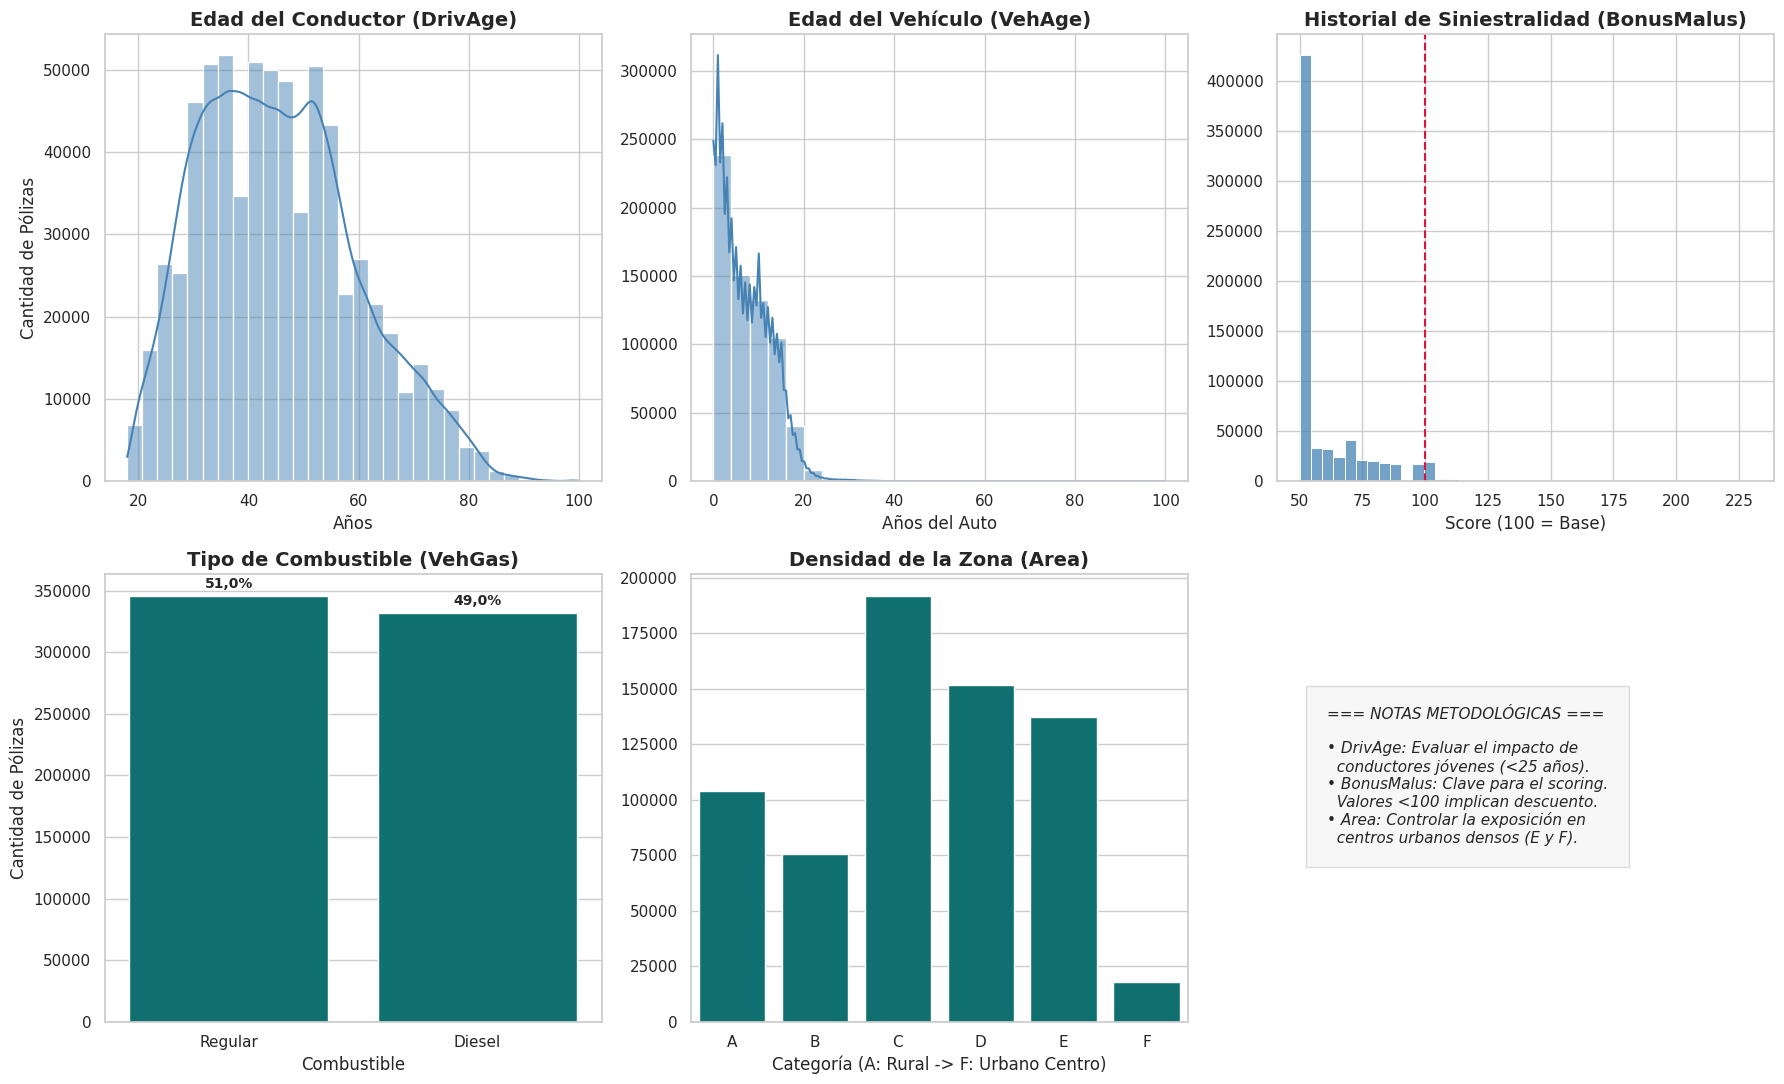

In [130]:
# ==============================================================================
# GRILLA DE GRÁFICOS: ANÁLISIS DE FEATURES DE RIESGO
# ==============================================================================
# Creamos un lienzo de 2 filas y 3 columnas (6 gráficos en total)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Definimos una paleta de colores base para mantener la armonía
color_continuas = 'steelblue'
color_categoricas = 'teal'

# ------------------------------------------------------------------------------
# 1. Distribución de la Edad del Conductor (DrivAge)
# ------------------------------------------------------------------------------
sns.histplot(data=df_freq, x='DrivAge', bins=30, kde=True, color=color_continuas, ax=axes[0, 0])
axes[0, 0].set_title('Edad del Conductor (DrivAge)', fontweight='bold')
axes[0, 0].set_xlabel('Años')
axes[0, 0].set_ylabel('Cantidad de Pólizas')

# ------------------------------------------------------------------------------
# 2. Distribución de la Edad del Vehículo (VehAge)
# ------------------------------------------------------------------------------
sns.histplot(data=df_freq, x='VehAge', bins=25, kde=True, color=color_continuas, ax=axes[0, 1])
axes[0, 1].set_title('Edad del Vehículo (VehAge)', fontweight='bold')
axes[0, 1].set_xlabel('Años del Auto')
axes[0, 1].set_ylabel('')

# ------------------------------------------------------------------------------
# 3. Distribución del Bonus / Malus
# ------------------------------------------------------------------------------
sns.histplot(data=df_freq, x='BonusMalus', bins=40, kde=False, color=color_continuas, ax=axes[0, 2])
axes[0, 2].set_title('Historial de Siniestralidad (BonusMalus)', fontweight='bold')
axes[0, 2].set_xlabel('Score (100 = Base)')
axes[0, 2].set_ylabel('')
# Dibujamos una línea roja en el 100 para marcar comercialmente el límite Bonus/Malus
axes[0, 2].axvline(100, color='crimson', linestyle='--', linewidth=1.5, label='Base (100)')

# ------------------------------------------------------------------------------
# 4. Tipo de Combustible (VehGas)
# ------------------------------------------------------------------------------
sns.countplot(data=df_freq, x='VehGas', color=color_categoricas, ax=axes[1, 0], order=df_freq['VehGas'].value_counts().index)
axes[1, 0].set_title('Tipo de Combustible (VehGas)', fontweight='bold')
axes[1, 0].set_xlabel('Combustible')
axes[1, 0].set_ylabel('Cantidad de Pólizas')

# Añadir porcentajes a las barras de combustible
total_gas = len(df_freq)
for p in axes[1, 0].patches:
    pct = f'{100 * p.get_height() / total_gas:.1f}%'.replace('.', ',')
    axes[1, 0].annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontsize=10, fontweight='semibold')

# ------------------------------------------------------------------------------
# 5. Zona de Residencia (Area)
# ------------------------------------------------------------------------------
# Ordenamos de la A (Rural) a la F (Urbano Centro)
orden_area = sorted(df_freq['Area'].unique())
sns.countplot(data=df_freq, x='Area', order=orden_area, color=color_categoricas, ax=axes[1, 1])
axes[1, 1].set_title('Densidad de la Zona (Area)', fontweight='bold')
axes[1, 1].set_xlabel('Categoría (A: Rural -> F: Urbano Centro)')
axes[1, 1].set_ylabel('')

# ------------------------------------------------------------------------------
# 6. Espacio vacío o Análisis extra (Lo usamos para limpiar el diseño)
# ------------------------------------------------------------------------------
# Apagamos los ejes del último cuadrante para que no quede un gráfico en blanco feo
axes[1, 2].axis('off')
# Metemos un cuadro de texto explicativo en ese espacio vacío con estilo de consultoría
texto_resumen = (
    "=== NOTAS METODOLÓGICAS ===\n\n"
    "• DrivAge: Evaluar el impacto de\n"
    "  conductores jóvenes (<25 años).\n"
    "• BonusMalus: Clave para el scoring.\n"
    "  Valores <100 implican descuento.\n"
    "• Area: Controlar la exposición en\n"
    "  centros urbanos densos (E y F)."
)
axes[1, 2].text(0.1, 0.4, texto_resumen, fontsize=11, style='italic',
                bbox={'facecolor': 'whitesmoke', 'alpha': 0.8, 'pad': 15, 'edgecolor': 'lightgray'})

# Optimización del espacio entre los subplots
plt.tight_layout()
plt.show()

In [134]:
# ==============================================================================
# TABLA DE FRECUENCIA: DISTRIBUCIÓN COMPLETA DE MARCAS (SIN AGRUPAR)
# ==============================================================================
# 1. Calculamos la distribución pura de las 11 marcas originales
tabla_brand_completa = df_freq['VehBrand'].value_counts().reset_index()
tabla_brand_completa.columns = ['Marca_Vehículo', 'Cantidad_Pólizas']

# 2. Calculamos el porcentaje sobre el total de la cartera
total_polizas = len(df_freq)
tabla_brand_completa['Porcentaje'] = (tabla_brand_completa['Cantidad_Pólizas'] / total_polizas) * 100

# 3. Formateamos la visualización para el reporte técnico
tabla_brand_formatted = tabla_brand_completa.copy()
tabla_brand_formatted['Cantidad_Pólizas'] = tabla_brand_formatted['Cantidad_Pólizas'].apply(lambda x: f"{x:,}".replace(',', '.'))
tabla_brand_formatted['Porcentaje'] = tabla_brand_formatted['Porcentaje'].apply(lambda x: f"{x:.2f}%".replace('.', ','))

print("=== DISTRIBUCIÓN COMPLETA DE MARCAS DE VEHÍCULOS ===")
print(tabla_brand_formatted.to_string(index=False))
print("-" * 52)
print(f"Total de marcas únicas detectadas: {df_freq['VehBrand'].nunique()}")

=== DISTRIBUCIÓN COMPLETA DE MARCAS DE VEHÍCULOS ===
Marca_Vehículo Cantidad_Pólizas Porcentaje
           B12          166.024     24,49%
            B1          162.736     24,00%
            B2          159.861     23,58%
            B3           53.395      7,88%
            B5           34.753      5,13%
            B6           28.548      4,21%
            B4           25.179      3,71%
           B10           17.707      2,61%
           B11           13.585      2,00%
           B13           12.178      1,80%
           B14            4.047      0,60%
----------------------------------------------------
Total de marcas únicas detectadas: 11


In [139]:
df_freq['Region'].nunique()

21

In [137]:
# ==============================================================================
# ANÁLISIS BIVARIANTE: MARCA DEL VEHÍCULO VS SINIESTRALIDAD (RIESGO)
# ==============================================================================
# 1. Agrupamos la base de frecuencia por marca y sumamos Exposición y Siniestros
tabla_riesgo_brand = df_freq.groupby('VehBrand').agg(
    Cantidad_Pólizas=('IDpol', 'count'),
    Exposición_Total=('Exposure', 'sum'),
    Siniestros_Totales=('ClaimNb', 'sum')
).reset_index()

# 2. Calculamos la Frecuencia Anualizada (La métrica clave de riesgo)
# Multiplicamos por 100 para expresarlo como porcentaje de choques por año
tabla_riesgo_brand['Frecuencia_Anualizada'] = (tabla_riesgo_brand['Siniestros_Totales'] / tabla_riesgo_brand['Exposición_Total']) * 100

# 3. Ordenamos la tabla de mayor a menor riesgo para que salte a la vista la peor marca
tabla_riesgo_brand = tabla_riesgo_brand.sort_values(by='Frecuencia_Anualizada', ascending=False)

# 4. Formateamos los números para el reporte ejecutivo
tabla_brand_reporte = tabla_riesgo_brand.copy()
tabla_brand_reporte['Cantidad_Pólizas'] = tabla_brand_reporte['Cantidad_Pólizas'].apply(lambda x: f"{x:,}".replace(',', '.'))
tabla_brand_reporte['Exposición_Total'] = tabla_brand_reporte['Exposición_Total'].apply(lambda x: f"{x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
tabla_brand_reporte['Siniestros_Totales'] = tabla_brand_reporte['Siniestros_Totales'].apply(lambda x: f"{x:,}".replace(',', '.'))
tabla_brand_reporte['Frecuencia_Anualizada'] = tabla_brand_reporte['Frecuencia_Anualizada'].apply(lambda x: f"{x:.2f}%".replace('.', ','))

print("=== RANKING DE RIESGO POR MARCA DE VEHÍCULO ===")
print(tabla_brand_reporte.to_string(index=False))
print("-" * 75)

=== RANKING DE RIESGO POR MARCA DE VEHÍCULO ===
VehBrand Cantidad_Pólizas Exposición_Total Siniestros_Totales Frecuencia_Anualizada
     B12          166.024        64.808,61              8.859                13,67%
     B11           13.585         6.887,82                721                10,47%
      B5           34.753        19.992,06              2.020                10,10%
      B3           53.395        28.592,88              2.818                 9,86%
     B13           12.178         6.772,03                649                 9,58%
      B4           25.179        13.775,50              1.312                 9,52%
      B6           28.548        15.684,95              1.462                 9,32%
      B1          162.736        95.351,06              8.677                 9,10%
     B10           17.707         9.496,01                858                 9,04%
      B2          159.861        94.864,06              8.560                 9,02%
     B14            4.047   

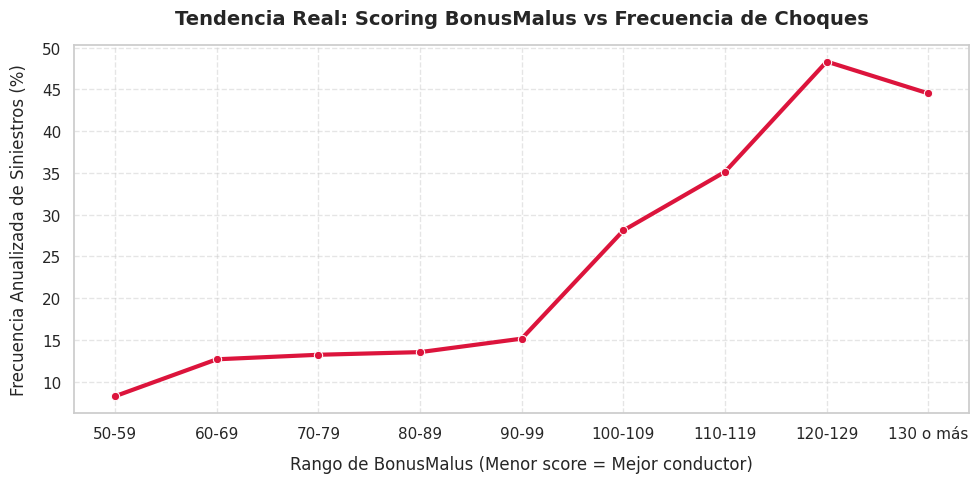

In [142]:
# ==============================================================================
# ANÁLISIS BIVARIANTE CORREGIDO: BONUS/MALUS AGRUPADO VS RIESGO
# ==============================================================================
# 1. Creamos rangos controlados: de 50 a 120 de a 10 puntos, y agrupamos el resto
def tramos_bonus_malus(x):
    if x < 60:  return '50-59'
    elif x < 70: return '60-69'
    elif x < 80: return '70-79'
    elif x < 90: return '80-89'
    elif x < 100: return '90-99'
    elif x < 110: return '100-109'
    elif x < 120: return '110-119'
    elif x < 130: return '120-129'
    else:         return '130 o más'

# Aplicamos la agrupación
df_freq['BonusMalus_CleanRange'] = df_freq['BonusMalus'].apply(tramos_bonus_malus)

# Definimos el orden lógico del eje X
orden_bm = ['50-59', '60-69', '70-79', '80-89', '90-99', '100-109', '110-119', '120-129', '130 o más']

# 2. Agrupamos por rango y calculamos la Frecuencia Anualizada
df_bm_clean = df_freq.groupby('BonusMalus_CleanRange').agg(
    Exposición_Total=('Exposure', 'sum'),
    Siniestros_Totales=('ClaimNb', 'sum')
).reindex(orden_bm).reset_index()

df_bm_clean['Frecuencia_Anualizada'] = (df_bm_clean['Siniestros_Totales'] / df_bm_clean['Exposición_Total']) * 100

# 3. Graficamos la tendencia limpia
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_bm_clean,
    x='BonusMalus_CleanRange',
    y='Frecuencia_Anualizada',
    marker='o',
    linewidth=3,
    color='crimson'
)

plt.title('Tendencia Real: Scoring BonusMalus vs Frecuencia de Choques', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rango de BonusMalus (Menor score = Mejor conductor)', fontsize=12, labelpad=10)
plt.ylabel('Frecuencia Anualizada de Siniestros (%)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
# Forzamos a que pinte las 9 etiquetas del orden de forma explícita
plt.xticks(range(len(orden_bm)), orden_bm)

plt.tight_layout()
plt.show()